Este Jupyter Notebook foi criado para uso exclusivo no o curso MAC0209 - Modelagem e Simulação.

Roberto M. Cesar Jr

rmcesar@usp.br

# Convolução 1D

Sinal original: [1 2 3 4 5]
Filtro aplicado: [ 1  0 -1]
Resultado da convolução: [2 2 2]


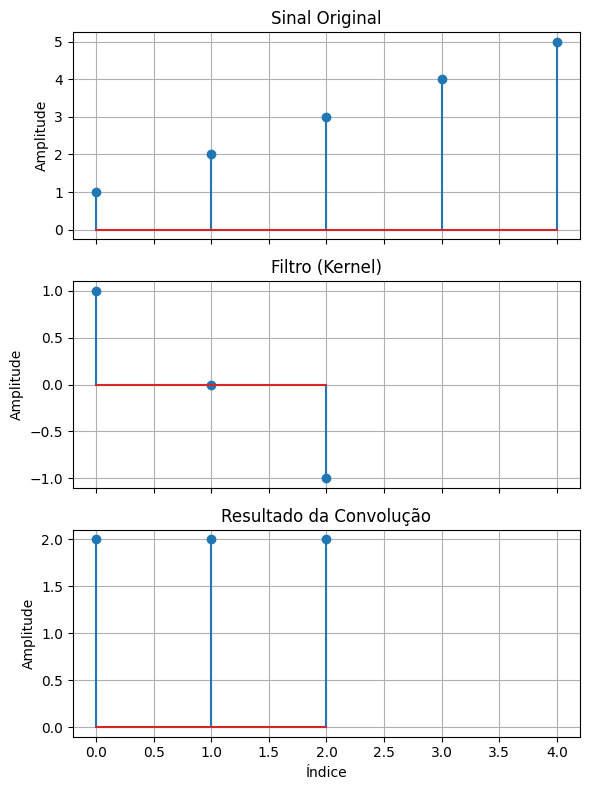

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def main():
    # Criando um vetor 1D para representar um sinal discreto
    sinal = np.array([1, 2, 3, 4, 5])

    # Definindo um kernel (filtro) para a convolução
    filtro = np.array([1, 0, -1])

    # Aplicando a convolução 1D
    resultado = np.convolve(sinal, filtro, mode='valid')

    # Exibindo os resultados
    print("Sinal original:", sinal)
    print("Filtro aplicado:", filtro)
    print("Resultado da convolução:", resultado)

    # Criando gráfico para visualizar o processo
    fig, axs = plt.subplots(3, 1, figsize=(6, 8), sharex=True)

    # Plotando o sinal original
    axs[0].stem(sinal)
    axs[0].set_title("Sinal Original")
    axs[0].set_ylabel("Amplitude")
    axs[0].grid()

    # Plotando o filtro (kernel)
    axs[1].stem(filtro)
    axs[1].set_title("Filtro (Kernel)")
    axs[1].set_ylabel("Amplitude")
    axs[1].grid()

    # Plotando o resultado da convolução
    axs[2].stem(resultado)
    axs[2].set_title("Resultado da Convolução")
    axs[2].set_xlabel("Índice")
    axs[2].set_ylabel("Amplitude")
    axs[2].grid()

    # Ajustar espaçamento entre subgráficos
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()


# Convolução 2D

Saving amelie.png to amelie.png
Imagem: amelie.png
Shape original: (631, 512)


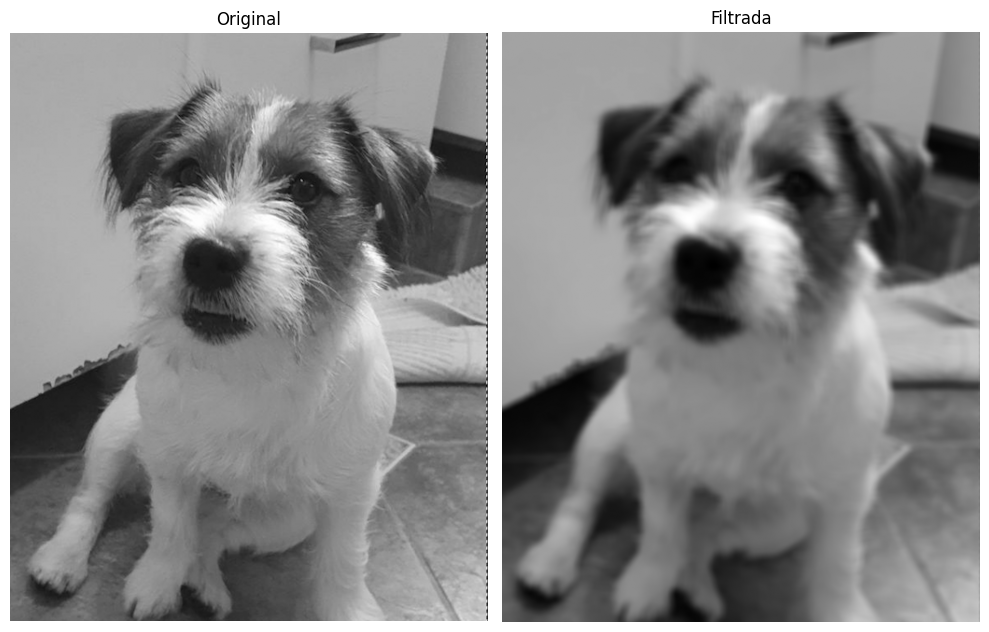

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image
import io


def carregar_imagem():
    uploaded = files.upload()
    nome = list(uploaded.keys())[0]

    img = Image.open(io.BytesIO(uploaded[nome])).convert("L")
    img = np.array(img, dtype=float)

    return nome, img


def convolucao_linhas(img, filtro):
    h, w = img.shape
    out_w = w - len(filtro) + 1
    out = np.zeros((h, out_w))

    for i in range(h):
        out[i, :] = np.convolve(img[i, :], filtro, mode="valid")

    return out

def main():
    tamanho_filtro = 9
    filtro = np.ones(tamanho_filtro) / tamanho_filtro

    nome, img = carregar_imagem()

    # Horizontal (linhas)
    horiz = convolucao_linhas(img, filtro)

    # Vertical (colunas via transpose)
    result_n = convolucao_linhas(horiz.T, filtro).T

    print("Imagem:", nome)
    print("Shape original:", img.shape)

    fig, axs = plt.subplots(1, 2, figsize=(10, 10))

    axs[0].imshow(img, cmap="gray")
    axs[0].set_title("Original")
    axs[0].axis("off")

    axs[1].imshow(result_n, cmap="gray")
    axs[1].set_title("Filtrada")
    axs[1].axis("off")

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()